# Emperical Verification For Step Size

- **Objective:** Verify whether the chosen learning rate (step size) enables stable convergence of Stochastic Gradient Descent (SGD).

- **Empirical Verification:**
  - Train the model using different learning rates (e.g., 0.001, 0.01, 0.03, 0.1).
  - Compare the training and validation loss curves.
  - A suitable learning rate should result in:
    - Smooth decrease in training loss.
    - Stable convergence of validation loss.
    - No oscillations or divergence.

- **Interpretation:**
  - Very small learning rates lead to slow convergence.
  - Very large learning rates cause unstable optimization and may diverge.
  - An intermediate learning rate achieves the fastest stable convergence.

- **Limitation:**
  - The implementation uses a **constant learning rate** throughout training.
  - Therefore, the practical convergence behavior can be verified empirically, but the theoretical Robbins-Monro diminishing step-size condition is **not satisfied**. Hence, formal convergence guarantees cannot be established.


In [1]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

In [9]:
lr_rates = {
'stepsize_lower_lr': 0.001,
'stepsize_moderate_lr': 0.01,
'stepsize_higher_lr': 0.03,
'stepsize_highest_lr': 0.1
}


In [5]:
step_size_results_path = '../results/stepsize_results.csv'
df = pd.read_csv(step_size_results_path)

In [6]:
df = (
    df.groupby(["run", "metric", "epoch"], as_index=False)
      .agg(value=("value", "mean"))
)

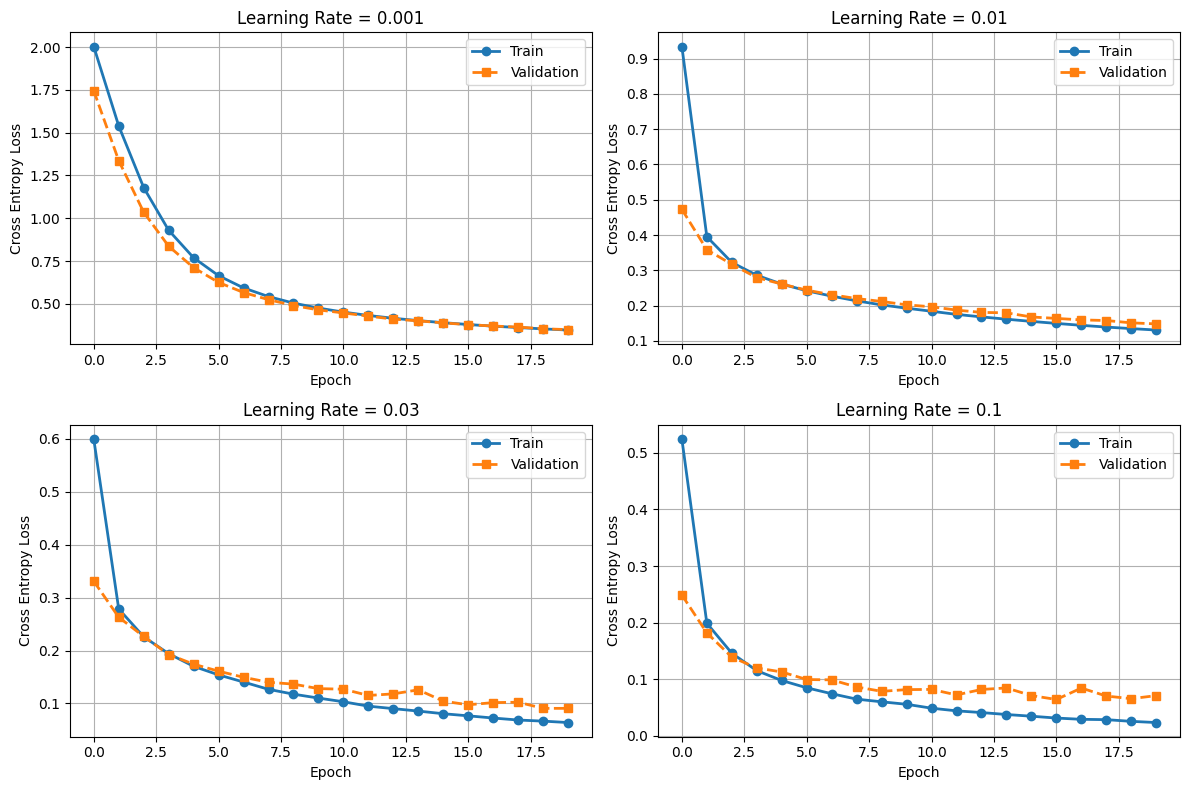

In [20]:
loss_df = df[df["metric"].isin(["Loss/train", "Loss/val"])]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

runs = list(lr_rates.keys())

for ax, run in zip(axes, runs):

    train = loss_df[(loss_df["run"] == run) &(loss_df["metric"] == "Loss/train")]

    val = loss_df[(loss_df["run"] == run) &(loss_df["metric"] == "Loss/val")]

    ax.plot(train["epoch"],train["value"],marker="o",linewidth=2,label="Train")

    ax.plot(val["epoch"],val["value"],marker="s",linewidth=2,linestyle="--",label="Validation")

    ax.set_title(f"Learning Rate = {lr_rates[run]}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross Entropy Loss")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

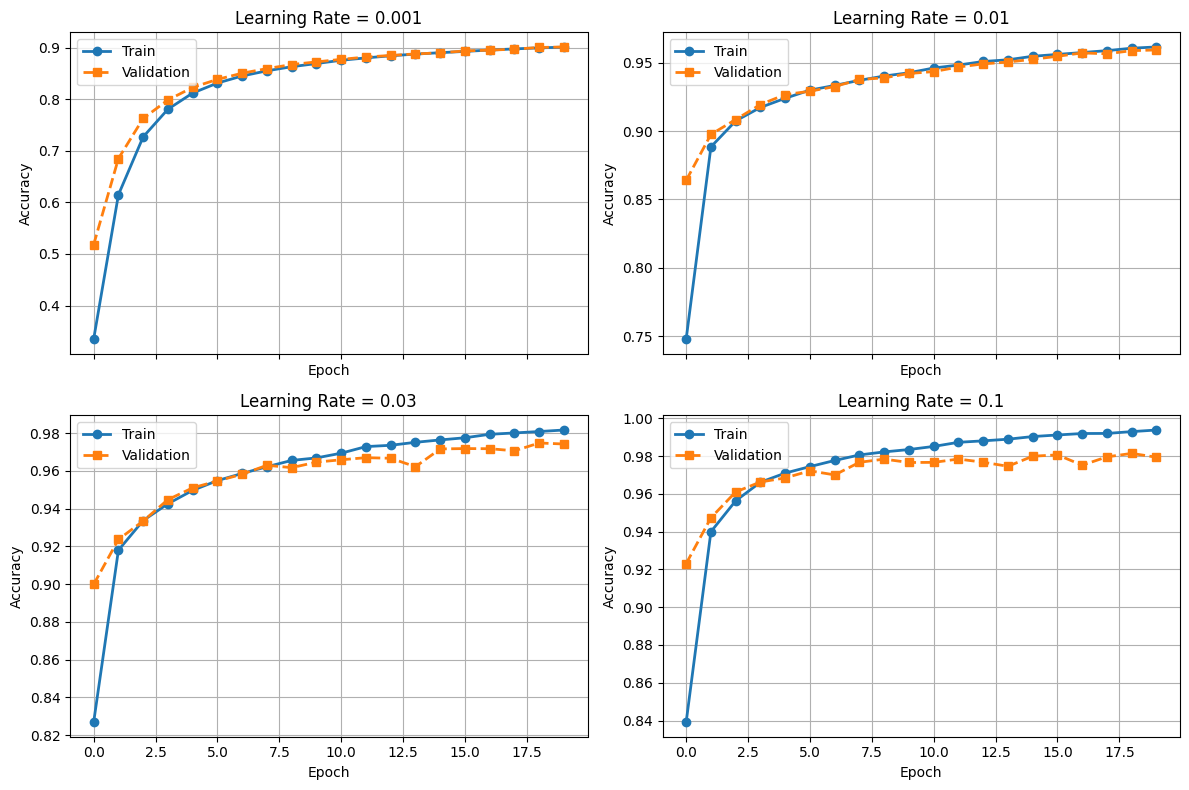

In [19]:
acc_df = df[df["metric"].isin(["Accuracy/train", "Accuracy/val"])]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

runs = list(lr_rates.keys())

for ax, run in zip(axes, runs):

    train = acc_df[(acc_df["run"] == run) & (acc_df["metric"] == "Accuracy/train")]
    val = acc_df[(acc_df["run"] == run) & (acc_df["metric"] == "Accuracy/val")]

    ax.plot(train["epoch"], train["value"], marker="o", linewidth=2, label="Train")
    ax.plot(val["epoch"], val["value"], marker="s", linewidth=2, linestyle="--", label="Validation")

    ax.set_title(f"Learning Rate = {lr_rates[run]}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

### What do these curves tell?

Four learning rates (0.001, 0.01, 0.03 and 0.1) were evaluated to study the effect of step size on SGD convergence.

#### Observations
- **0.001:** Stable but slow convergence, resulting in the lowest final accuracy.
- **0.01:** Fast convergence with closely matching training and validation curves, indicating stable optimization and good generalization.
- **0.03:** Converges slightly faster than 0.01 but exhibits a small train-validation gap towards later epochs.
- **0.1:** Converges the fastest initially but shows fluctuations in validation accuracy, indicating reduced optimization stability.

#### Conclusion
- Increasing the learning rate improves convergence up to an optimal value.
- A learning rate of **0.01** provides the best trade-off between convergence speed, optimization stability and validation performance for this problem.
- Since a constant learning rate is used, empirical convergence is verified, but the theoretical Robbins-Monro diminishing step-size condition is not satisfied.